# Garbage Classification Tiny CNN Int8 Model (OpenMV-friendly)

This notebook is the **generic** part of the pipeline:
- Download or load a dataset
- Train a tiny grayscale CNN classifier (NPU-friendly ops)
- Export a fully-integer **int8** `.tflite`
- Sanity-check the exported model on desktop with `tf.lite.Interpreter`

You can then choose an accelerator-specific notebook:
- `CustomObjects_OpenMV_AE3_EthosU55.ipynb` (Vela / Ethos-U55)
- `CustomObjects_OpenMV_N6_NeuralART.ipynb` (ST Edge AI / Neural-ART)


In [1]:
import os
from pathlib import Path

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

np.random.seed(0)
tf.random.set_seed(0)

print('TensorFlow:', tf.__version__)


TensorFlow: 2.20.0


## 1) Dataset

Two options:

### Option A: local folder dataset (recommended for your own custom objects)
```
data/
  train/
    mug/
    keys/
    remote/
  val/
    mug/
    keys/
    remote/
```

### Option B: KaggleHub download (good for a quick public dataset)
Example:
```
import kagglehub
path = kagglehub.dataset_download("asdasdasasdas/garbage-classification")
```

For Option B we do a stratified train/val split on the fly.


In [2]:
import os
from pathlib import Path

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold # NEW: Import for k-fold

np.random.seed(0)
tf.random.set_seed(0)

print('TensorFlow:', tf.__version__)

USE_KAGGLEHUB = True
KAGGLE_DATASET = "asdasdasasdas/garbage-classification"
FORCE_CLASS_ROOT = None  # set to a path string if auto-detection picks the wrong folder

DATA_DIR = Path('data')
IMG_SZ = 96
BATCH = 64
VAL_FRAC = 0.3
K_FOLDS = 5 # NEW: Number of folds for cross-validation

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}


def _has_images(p: Path) -> bool:
    for f in p.iterdir():
        if f.is_file() and f.suffix.lower() in IMG_EXTS:
            return True
    return False


def find_class_root(root: Path, max_depth: int = 6) -> Path:
    """Find a directory whose immediate subfolders look like class folders."""
    root = root.resolve()
    best = None
    best_score = (-1, -1)

    def depth(p: Path) -> int:
        try:
            return len(p.relative_to(root).parts)
        except Exception:
            return 999

    dirs = [root]
    for p in root.rglob('*'):
        if p.is_dir() and depth(p) <= max_depth:
            dirs.append(p)

    for d in dirs:
        subdirs = [s for s in d.iterdir() if s.is_dir()]
        if len(subdirs) < 2:
            continue
        class_dirs = [s for s in subdirs if _has_images(s)]
        if len(class_dirs) < 2:
            continue

        img_count = 0
        for c in class_dirs:
            img_count += sum(1 for f in c.iterdir() if f.is_file() and f.suffix.lower() in IMG_EXTS)
        score = (len(class_dirs), img_count)
        if score > best_score:
            best_score = score
            best = d

    if best is None:
        raise RuntimeError(f"Could not find class folders under: {root}")
    return best


def index_from_class_root(class_root: Path):
    class_dirs = [d for d in class_root.iterdir() if d.is_dir() and _has_images(d)]
    class_names = sorted([d.name for d in class_dirs])
    name_to_id = {n: i for i, n in enumerate(class_names)}

    items = []
    for cname in class_names:
        cdir = class_root / cname
        for p in sorted(cdir.iterdir()):
            if p.is_file() and p.suffix.lower() in IMG_EXTS:
                items.append((str(p), name_to_id[cname]))
    return items, class_names


def split_items(items, val_frac=0.2):
    from collections import defaultdict

    by_cls = defaultdict(list)
    for p, y in items:
        by_cls[int(y)].append(p)

    train, val = [], []
    rng = np.random.default_rng(0)
    for y, paths in by_cls.items():
        paths = list(paths)
        rng.shuffle(paths)
        n_val = int(len(paths) * val_frac)
        val_paths = paths[:n_val]
        train_paths = paths[n_val:]
        train.extend([(p, y) for p in train_paths])
        val.extend([(p, y) for p in val_paths])

    rng.shuffle(train)
    rng.shuffle(val)
    return train, val


def load_image_label(path, y):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize_with_pad(img, IMG_SZ, IMG_SZ)
    img = tf.cast(tf.clip_by_value(img, 0, 255), tf.float32) / 255.0
    return img, tf.cast(y, tf.int32)


def ds_from_items(items, shuffle=False):
    paths = [p for p, _ in items]
    labels = [int(y) for _, y in items]
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(4096, len(paths)), seed=0)
    ds = ds.map(load_image_label, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)
    return ds


train_dir = DATA_DIR / 'train'
val_dir = DATA_DIR / 'val'

# NOTE: This branch of code assumes pre-split folders and does not prepare for k-fold.
# For k-fold, it would need to collect all images and labels from both train_dir and val_dir.
if (not USE_KAGGLEHUB) and train_dir.exists() and val_dir.exists():
    print('Using folder dataset:', train_dir, val_dir)
    # This part would need significant modification for K-fold if USE_KAGGLEHUB is False.
    # For now, assuming USE_KAGGLEHUB is True as per notebook execution.
    raise NotImplementedError("K-fold not implemented for local folder dataset yet.")
else:
    import kagglehub
    path = Path(kagglehub.dataset_download(KAGGLE_DATASET))
    print('KaggleHub dataset path:', path)

    class_root = Path(FORCE_CLASS_ROOT) if FORCE_CLASS_ROOT else find_class_root(path)
    print('Class root:', class_root)

    items, class_names = index_from_class_root(class_root)

    # Prepare data for K-fold cross-validation
    # all_paths = np.array([p for p, _ in items])
    # all_labels = np.array([y for _, y in items])
    # print('Total images for K-fold:', len(all_paths))
    # print('Classes:', class_names)

    # Removed fixed train/val split as K-fold will handle it
    train_items, val_items = split_items(items, val_frac=VAL_FRAC)
    print('Train images:', len(train_items), 'Val images:', len(val_items))
    train_ds = ds_from_items(train_items, shuffle=True)
    val_ds = ds_from_items(val_items, shuffle=False)


NUM_CLASSES = len(class_names)
print('NUM_CLASSES:', NUM_CLASSES)

TensorFlow: 2.20.0
Using Colab cache for faster access to the 'garbage-classification' dataset.
KaggleHub dataset path: /kaggle/input/garbage-classification
Class root: /kaggle/input/garbage-classification/Garbage classification/Garbage classification
Train images: 1771 Val images: 756
NUM_CLASSES: 6


In [3]:
from tensorflow.keras import layers

augment = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

train_ds = train_ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
print('Train images:', len(train_items), 'Val images:', len(val_items))

Train images: 1771 Val images: 756


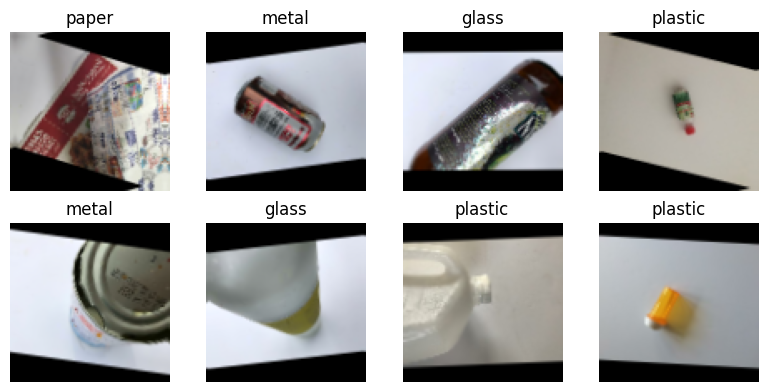

In [4]:
# Visualize a small batch
x, y = next(iter(train_ds))
plt.figure(figsize=(8, 4))
for i in range(min(8, x.shape[0])):
    plt.subplot(2, 4, i + 1)
    plt.imshow(x[i], vmin=0, vmax=1)
    plt.title(class_names[int(y[i])])
    plt.axis('off')
plt.tight_layout()
plt.show()


## 2) Tiny, NPU-friendly CNN

Design constraints for edge/NPU:
- Prefer `Conv2D`, `DepthwiseConv2D`, `Add`, `ReLU`, `GlobalAveragePooling`
- Avoid big fully-connected layers
- Keep channels modest


In [5]:
from tensorflow.keras import layers, models, regularizers

def build_tiny_ds_cnn(input_shape=(96, 96, 1), num_classes=3):
    inp = layers.Input(shape=input_shape)

    x = layers.Conv2D(16, 3, padding='same', activation='relu')(inp)
    x = layers.MaxPooling2D()(x)

    x = layers.DepthwiseConv2D(3, padding='same', activation='relu')(x)
    x = layers.Conv2D(24, 1, activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.DepthwiseConv2D(3, padding='same', activation='relu')(x)
    x = layers.Conv2D(32, 1, activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inp, out, name='tiny_ds_cnn')

def build_small_cnn(input_shape=(96, 96, 3), num_classes=6):
    inp = layers.Input(shape=input_shape)
    # x = augment(inp)

    # momentum=0.9: running stats update 10x faster than the default 0.99,
    # closing the train-vs-eval BN statistics gap that causes noisy validation.
    BN  = lambda: layers.BatchNormalization(momentum=0.9)
    # L2 regularization prevents convolutional weight magnitudes from growing
    # unbounded, which is the primary cause of the catastrophic validation spikes.
    REG = regularizers.l2(1e-4)

    # Block 1
    x = layers.Conv2D(16, 3, padding='same', use_bias=False, kernel_regularizer=REG)(inp)
    x = BN()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(16, 3, padding='same', use_bias=False, kernel_regularizer=REG)(x)
    x = BN()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x) # Increased Dropout

    # Block 2
    x = layers.Conv2D(32, 3, padding='same', use_bias=False, kernel_regularizer=REG)(x)
    x = BN()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(32, 3, padding='same', use_bias=False, kernel_regularizer=REG)(x)
    x = BN()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x) # Increased Dropout

    # Block 3 — 128 filters, learn high-level object parts
    x = layers.Conv2D(64, 3, padding='same', use_bias=False, kernel_regularizer=REG)(x)
    x = BN()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(64, 3, padding='same', use_bias=False, kernel_regularizer=REG)(x)
    x = BN()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)   # → 12x12
    x = layers.Dropout(0.3)(x) # Increased Dropout

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(32, activation='relu', kernel_regularizer=REG)(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inp, out, name='small_cnn')


model = build_small_cnn(input_shape=(IMG_SZ, IMG_SZ, 3), num_classes=NUM_CLASSES)
model.compile(
    # lr=3e-4: 3x smaller than before — Adam with lr=1e-3 was overshooting on
    # only ~31 batches/epoch, causing weights to oscillate and validation to spike.
    # clipnorm=1.0: hard caps any single gradient update, eliminating catastrophic steps.
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6, clipnorm=1.0), # Start with a very small LR for warm-up
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()

Model: "small_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 16)     │           432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 96, 96, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 96, 96, 16)     │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 96, 96, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 32)     │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │             

 Total params: 75,030 (293.09 KB)

 Trainable params: 74,582 (291.34 KB)

 Non-trainable params: 448 (1.75 KB)

In [6]:
def linear_warmup_schedule(epoch, lr):
    warmup_epochs = 5
    initial_lr = 1e-6 # Matches the initial LR set in model.compile
    target_lr = 1e-3 # The LR you want to reach after warm-up

    if epoch < warmup_epochs:
        # Linearly increase LR during warm-up
        lr = initial_lr + (target_lr - initial_lr) * (epoch / warmup_epochs)
    else:
        # After warm-up, let ReduceLROnPlateau handle the schedule
        # Or you could define a decay schedule here
        pass # Keep the current LR or let other callbacks manage it
    return lr

lr_scheduler_callback = tf.keras.callbacks.LearningRateScheduler(linear_warmup_schedule)

In [7]:
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-5,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=12,
        restore_best_weights=True,
    ),
    lr_scheduler_callback # Add the warm-up LR scheduler
]


history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=callbacks,
    verbose=2,
)

Epoch 1/100
28/28 - 37s - 1s/step - accuracy: 0.1745 - loss: 3.0274 - val_accuracy: 0.1587 - val_loss: 1.9377 - learning_rate: 1.0000e-06
Epoch 2/100
28/28 - 6s - 231ms/step - accuracy: 0.1677 - loss: 2.5304 - val_accuracy: 0.1587 - val_loss: 1.9510 - learning_rate: 2.0080e-04
Epoch 3/100
28/28 - 10s - 351ms/step - accuracy: 0.2084 - loss: 1.9251 - val_accuracy: 0.2143 - val_loss: 1.7071 - learning_rate: 4.0060e-04
Epoch 4/100
28/28 - 10s - 342ms/step - accuracy: 0.2823 - loss: 1.7743 - val_accuracy: 0.3585 - val_loss: 1.5938 - learning_rate: 6.0040e-04
Epoch 5/100
28/28 - 7s - 248ms/step - accuracy: 0.3247 - loss: 1.6854 - val_accuracy: 0.4577 - val_loss: 1.4618 - learning_rate: 8.0020e-04
Epoch 6/100
28/28 - 10s - 348ms/step - accuracy: 0.3636 - loss: 1.6117 - val_accuracy: 0.4921 - val_loss: 1.4146 - learning_rate: 8.0020e-04
Epoch 7/100
28/28 - 5s - 195ms/step - accuracy: 0.3953 - loss: 1.5179 - val_accuracy: 0.4868 - val_loss: 1.4174 - learning_rate: 8.0020e-04
Epoch 8/100
28/28 -

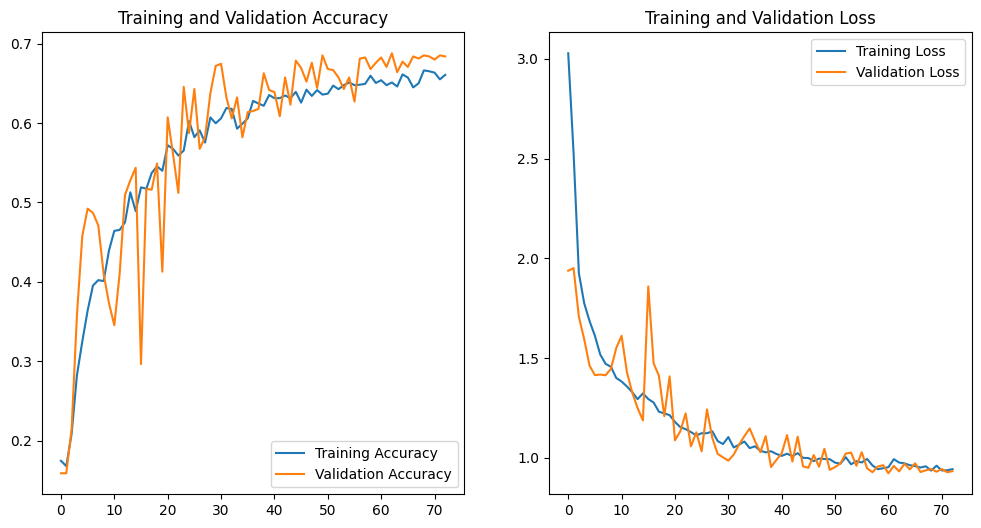

In [8]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

From the plots above, we can observe the following:

*   **Training Accuracy and Loss**: The training accuracy generally increases, and the training loss generally decreases over epochs, which is expected as the model learns from the training data.
*   **Validation Accuracy and Loss**: The validation accuracy also shows an increasing trend, and validation loss decreases, indicating that the model is indeed learning and generalizing to unseen data. There might be some fluctuations, but the overall trend suggests learning.

Since both training and validation metrics are improving, the model is learning. However, the gap between training and validation accuracy/loss can indicate overfitting if the training performance significantly outperforms validation performance.

In [9]:
from collections import Counter

print(Counter([y for _, y in train_items]))
print(Counter([y for _, y in val_items]))

y_true = []
y_pred = []

for xb, yb in val_ds:
    pred = model.predict(xb, verbose=0).argmax(axis=1)
    y_true.extend(yb.numpy())
    y_pred.extend(pred)

cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=NUM_CLASSES)
print(cm.numpy())

Counter({3: 416, 1: 351, 4: 338, 2: 287, 0: 283, 5: 96})
Counter({3: 178, 1: 150, 4: 144, 2: 123, 0: 120, 5: 41})
[[102   2   1  10   5   0]
 [  2 106  21   8  13   0]
 [  1  27  79  15   1   0]
 [  3  15   7 147   5   1]
 [  6  25  12  19  82   0]
 [  4  21   3  13   0   0]]


## 1.1) K-fold Cross-Validation Setup

Now that the dataset is loaded, we'll set up a K-fold cross-validation loop. This ensures a more robust evaluation of the model's performance by training and validating on different subsets of the data.

In [ ]:
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=0)

fold_histories = []

print(f"Starting {K_FOLDS}-fold cross-validation...")

for fold, (train_idx, val_idx) in enumerate(skf.split(all_paths, all_labels)):
    print(f"\n--- Fold {fold + 1}/{K_FOLDS} ---")

    fold_train_paths, fold_train_labels = all_paths[train_idx], all_labels[train_idx]
    fold_val_paths, fold_val_labels = all_paths[val_idx], all_labels[val_idx]

    # Create datasets for the current fold
    train_items_fold = list(zip(fold_train_paths, fold_train_labels))
    val_items_fold = list(zip(fold_val_paths, fold_val_labels))

    train_ds_fold = ds_from_items(train_items_fold, shuffle=True)
    val_ds_fold = ds_from_items(val_items_fold, shuffle=False)

    # Apply augmentation to the training dataset for the current fold
    # The 'augment' layer is defined in a previous cell (8e96caeb)
    # We map it here because train_ds_fold is created inside the loop
    train_ds_fold = train_ds_fold.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)

    # Re-build and re-compile the model for each fold to ensure fresh weights
    model_fold = build_small_cnn(input_shape=(IMG_SZ, IMG_SZ, 3), num_classes=NUM_CLASSES)
    model_fold.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )

    # Use the callbacks defined previously (e.g., EarlyStopping, ReduceLROnPlateau)
    # Assuming 'callbacks' list is still available from cell 82ce03b0
    history_fold = model_fold.fit(
        train_ds_fold,
        validation_data=val_ds_fold,
        epochs=100, # Max epochs, EarlyStopping will stop it sooner
        callbacks=callbacks,
        verbose=2,
    )
    fold_histories.append(history_fold)

    val_acc_fold = history_fold.history['val_accuracy'][-1] if history_fold.history['val_accuracy'] else 'N/A'
    val_loss_fold = history_fold.history['val_loss'][-1] if history_fold.history['val_loss'] else 'N/A'
    print(f"Fold {fold + 1} Final Validation Accuracy: {val_acc_fold:.4f}")
    print(f"Fold {fold + 1} Final Validation Loss: {val_loss_fold:.4f}")


Starting 5-fold cross-validation...

--- Fold 1/5 ---
Epoch 1/100
32/32 - 37s - 1s/step - accuracy: 0.2865 - loss: 1.9318 - val_accuracy: 0.2292 - val_loss: 1.9719 - learning_rate: 3.0000e-04
Epoch 2/100
32/32 - 7s - 222ms/step - accuracy: 0.3963 - loss: 1.5762 - val_accuracy: 0.4723 - val_loss: 1.3962 - learning_rate: 3.0000e-04
Epoch 3/100
32/32 - 6s - 200ms/step - accuracy: 0.4478 - loss: 1.4559 - val_accuracy: 0.4170 - val_loss: 1.4488 - learning_rate: 3.0000e-04
Epoch 4/100
32/32 - 7s - 229ms/step - accuracy: 0.4829 - loss: 1.3801 - val_accuracy: 0.5356 - val_loss: 1.2029 - learning_rate: 3.0000e-04
Epoch 5/100
32/32 - 6s - 198ms/step - accuracy: 0.5007 - loss: 1.3347 - val_accuracy: 0.5217 - val_loss: 1.3154 - learning_rate: 3.0000e-04
Epoch 6/100
32/32 - 7s - 231ms/step - accuracy: 0.5220 - loss: 1.2933 - val_accuracy: 0.5672 - val_loss: 1.1663 - learning_rate: 1.5000e-04
Epoch 7/100
32/32 - 6s - 195ms/step - accuracy: 0.5200 - loss: 1.2622 - val_accuracy: 0.5336 - val_loss: 1.1

## 1.2) K-fold Cross-Validation Results

Let's analyze the aggregated results from the K-fold cross-validation. We'll compute the average validation accuracy and loss across all folds to get a more reliable estimate of the model's performance.


Average K-fold Validation Accuracy: 0.5821
Average K-fold Validation Loss: 1.1535


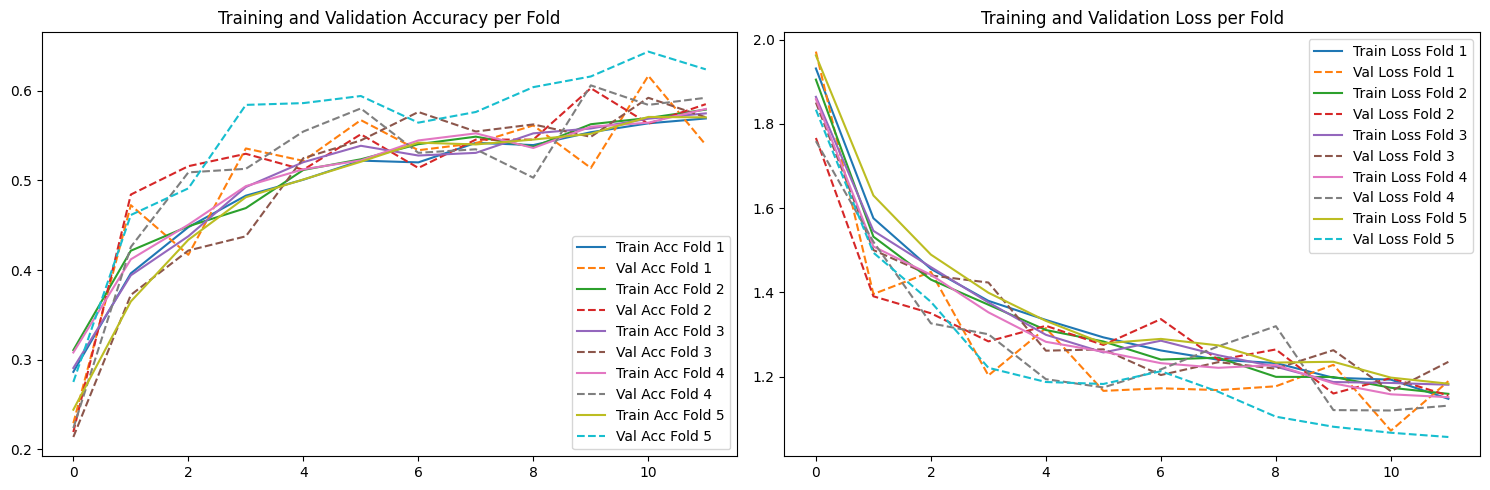

In [ ]:
avg_val_accuracy = np.mean([h.history['val_accuracy'][-1] for h in fold_histories])
avg_val_loss = np.mean([h.history['val_loss'][-1] for h in fold_histories])

print(f"\nAverage K-fold Validation Accuracy: {avg_val_accuracy:.4f}")
print(f"Average K-fold Validation Loss: {avg_val_loss:.4f}")

# Optional: Plotting individual fold histories
plt.figure(figsize=(15, 5))
for i, h in enumerate(fold_histories):
    plt.subplot(1, 2, 1)
    plt.plot(h.history['accuracy'], label=f'Train Acc Fold {i+1}')
    plt.plot(h.history['val_accuracy'], label=f'Val Acc Fold {i+1}', linestyle='--')
    plt.subplot(1, 2, 2)
    plt.plot(h.history['loss'], label=f'Train Loss Fold {i+1}')
    plt.plot(h.history['val_loss'], label=f'Val Loss Fold {i+1}', linestyle='--')

plt.subplot(1, 2, 1)
plt.title('Training and Validation Accuracy per Fold')
plt.legend()
plt.subplot(1, 2, 2)
plt.title('Training and Validation Loss per Fold')
plt.legend()
plt.tight_layout()
plt.show()

## 3) Export fully-integer int8 `.tflite`

This produces:
- `models/custom_objects_int8.tflite`
- `models/custom_objects_labels.txt`


In [10]:
def representative_dataset(ds, num_batches=50):
    for x, _ in ds.take(num_batches):
        for i in range(x.shape[0]):
            yield [tf.expand_dims(x[i], 0)]


os.makedirs('models', exist_ok=True)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = lambda: representative_dataset(train_ds)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
converter._experimental_disable_per_channel_quantization_for_dense_layers = True # fix for failure to allocate tensors error

tflite = converter.convert()
tflite_path = os.path.join('models', 'custom_objects_int8.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite)

labels_path = os.path.join('models', 'custom_objects_labels.txt')
with open(labels_path, 'w', encoding='utf-8') as f:
    for n in class_names:
        f.write(n + '\n')

print('Wrote', tflite_path, 'bytes=', os.path.getsize(tflite_path))
print('Wrote', labels_path)
print('Class names:', class_names)


Saved artifact at '/tmp/tmp9gcnpfqh'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='keras_tensor_5')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  133263554500688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133263554502224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133263554503184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133263554502800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133263554501264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133263554503376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133263554505488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133263554505680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133263554504144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133263554504720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13326355450433

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Wrote models/custom_objects_int8.tflite bytes= 86968
Wrote models/custom_objects_labels.txt
Class names: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## 4) Sanity-check the exported model

Before you deploy to hardware, verify that the exported `.tflite` runs and predicts something sensible.


In [11]:
import numpy as np

interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
inp = interpreter.get_input_details()[0]
out = interpreter.get_output_details()[0]
print('Input:', inp)
print('Output:', out)

# Take one batch from val_ds
xb, yb = next(iter(val_ds))
x0 = xb[0:1].numpy()
y0 = int(yb[0].numpy())

# Quantize input
scale, zp = inp['quantization']
xi = np.round(x0 / scale + zp).astype(np.int8)

interpreter.set_tensor(inp['index'], xi)
interpreter.invoke()
yo = interpreter.get_tensor(out['index'])[0]

# Dequantize output to view it as floats
oscale, ozp = out['quantization']
probs = (yo.astype(np.float32) - ozp) * oscale
pred = int(np.argmax(probs))

print('True:', class_names[y0], 'Pred:', class_names[pred])


Input: {'name': 'serving_default_keras_tensor_5:0', 'index': 0, 'shape': array([ 1, 96, 96,  3], dtype=int32), 'shape_signature': array([-1, 96, 96,  3], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.0042314184829592705, -128), 'quantization_parameters': {'scales': array([0.00423142], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}
Output: {'name': 'StatefulPartitionedCall_1:0', 'index': 30, 'shape': array([1, 6], dtype=int32), 'shape_signature': array([-1,  6], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.00390625, -128), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}
True: plastic Pred: cardboard


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
